In [97]:
import numpy as np
import matplotlib.pyplot as plt
from mnist import load_mnist_ubyte
from tqdm import tqdm
import scipy.ndimage

In [98]:
(x_train, y_train), (x_test, y_test) = load_mnist_ubyte()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

x_train = x_train.astype(np.float32)
x_test = x_test.astype(np.float32)

(60000, 784) (60000,)
(10000, 784) (10000,)


In [99]:
def relu(x):
    return np.maximum(0, x)

In [100]:
def relu_prime(x):
    return (x > 0).astype(np.float32)

In [101]:
def softmax(logits):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_scores = np.exp(shifted)
    return exp_scores / np.sum(exp_scores, axis=1, keepdims=True)

In [102]:
def cross_entropy_from_logits(logits, y):
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    log_sum_exp = np.log(np.sum(np.exp(shifted), axis=1, keepdims=True))
    log_probs = shifted - log_sum_exp
    return -np.mean(log_probs[np.arange(len(y)), y])

In [103]:
def one_hot(y, num_classes=10):
    Y = np.zeros((len(y), num_classes), dtype=np.float32)
    Y[np.arange(len(y)), y] = 1.0
    return Y

In [104]:
def accuracy_from_logits(logits, y):
    pred = np.argmax(logits, axis=1)
    return np.mean(pred == y)

In [105]:
class MLP:
    def __init__(self, H=2):
        self.H = H
        self.params = {}

        dims = [784] + [128] * (H + 1) + [10]

        for l in range(1, len(dims)):
            fan_in = dims[l - 1]
            fan_out = dims[l]
            self.params[f"W{l}"] = (
                np.random.randn(fan_in, fan_out).astype(np.float32) * np.sqrt(2.0 / fan_in)
            )
            self.params[f"b{l}"] = np.zeros((1, fan_out), dtype=np.float32)

        self.L = len(dims) - 1

    def forward(self, x):
        cache = {"A0": x}
        a = x

        for l in range(1, self.L):
            z = a @ self.params[f"W{l}"] + self.params[f"b{l}"]
            a = relu(z)
            cache[f"Z{l}"] = z
            cache[f"A{l}"] = a

        zL = a @ self.params[f"W{self.L}"] + self.params[f"b{self.L}"]
        cache[f"Z{self.L}"] = zL

        return zL, cache

    def backward(self, y, cache):
        grads = {}
        n = len(y)

        logits = cache[f"Z{self.L}"]
        probs = softmax(logits)
        Y = one_hot(y, num_classes=10)

        dZ = (probs - Y) / n

        A_prev = cache[f"A{self.L - 1}"]
        grads[f"W{self.L}"] = A_prev.T @ dZ
        grads[f"b{self.L}"] = np.sum(dZ, axis=0, keepdims=True)

        dA = dZ @ self.params[f"W{self.L}"].T

        for l in range(self.L - 1, 0, -1):
            dZ = dA * relu_prime(cache[f"Z{l}"])
            A_prev = cache[f"A{l - 1}"]

            grads[f"W{l}"] = A_prev.T @ dZ
            grads[f"b{l}"] = np.sum(dZ, axis=0, keepdims=True)

            if l > 1:
                dA = dZ @ self.params[f"W{l}"].T

        return grads

    def step(self, grads, lr=0.01):
        for l in range(1, self.L + 1):
            self.params[f"W{l}"] -= lr * grads[f"W{l}"]
            self.params[f"b{l}"] -= lr * grads[f"b{l}"]

In [106]:
def train(model, x_train, y_train, x_test, y_test, epochs=10, batch_size=64, lr=0.01):
    n = len(x_train)

    for epoch in range(epochs):
        for i in tqdm(range(0, n, batch_size)):
            x_batch = x_train[i:i+batch_size]
            y_batch = y_train[i:i+batch_size]

            logits, cache = model.forward(x_batch)
            loss = cross_entropy_from_logits(logits, y_batch)

            grads = model.backward(y_batch, cache)
            model.step(grads, lr=lr)

        test_logits, _ = model.forward(x_test)
        test_loss = cross_entropy_from_logits(test_logits, y_test)
        accuracy = accuracy_from_logits(test_logits, y_test)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, Test Loss: {test_loss:.4f}, Accuracy: {accuracy:.4f}")

In [107]:
model = MLP(H=2)
train(model, x_train, y_train, x_test, y_test, epochs=10, batch_size=64, lr=0.01)

100%|███████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 234.74it/s]


Epoch 1/10, Loss: 0.1657, Test Loss: 0.3272, Accuracy: 0.9026


100%|███████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 263.54it/s]


Epoch 2/10, Loss: 0.0955, Test Loss: 0.2580, Accuracy: 0.9218


100%|███████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 236.97it/s]


...

Epoch 8/10, Loss: 0.0347, Test Loss: 0.1458, Accuracy: 0.9564


100%|███████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 269.93it/s]


Epoch 9/10, Loss: 0.0327, Test Loss: 0.1382, Accuracy: 0.9585


100%|███████████████████████████████████████████████████████████████████████████████| 938/938 [00:03<00:00, 273.44it/s]


Epoch 10/10, Loss: 0.0305, Test Loss: 0.1315, Accuracy: 0.9601


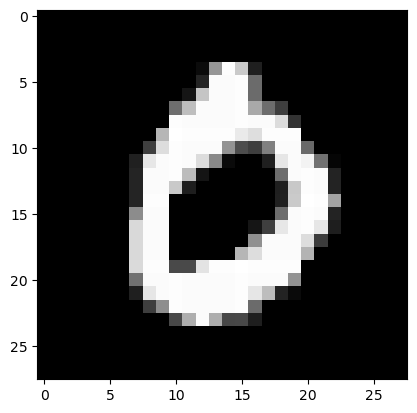

In [113]:
plt.imshow(x_test[3].reshape(28, 28), cmap="gray")
plt.show()

In [114]:
def predicted_details(res):
    for i, prob in enumerate(res):
        print(f"{i}: {prob*100:.2f}%")

In [115]:
logits, _ = model.forward(x_test[3:4])
probs = softmax(logits)[0]
predicted_details(probs)

0: 99.98%
1: 0.00%
2: 0.01%
3: 0.00%
4: 0.00%
5: 0.01%
6: 0.00%
7: 0.00%
8: 0.00%
9: 0.01%


In [116]:
def apply_transformation(image_vector, shift_x=0, shift_y=0, angle_rad=0):
    img = image_vector.reshape(28, 28)
    
    # 1. Rotation (angle_rad converti en degrés pour scipy)
    angle_deg = np.degrees(angle_rad)
    img = scipy.ndimage.rotate(img, angle_deg, reshape=False, mode='constant', cval=0)
    
    # 2. Translation
    img = scipy.ndimage.shift(img, shift=[shift_y, shift_x], mode='constant', cval=0)
    
    return img.flatten()

In [117]:
def evaluate_robustness(model, x_test, y_test, shifts=range(0, 15), angles=[0]):
    accuracies = []
    
    for s in shifts:
        # Création d'un batch test modifié
        x_modified = np.array([apply_transformation(x, shift_x=s, shift_y=s, angle_rad=0) for x in x_test])
        
        logits, _ = model.forward(x_modified)
        acc = accuracy_from_logits(logits, y_test)
        accuracies.append(acc)
        print(f"Shift {s}px: {acc:.4f}")
        
    return accuracies

In [118]:
shifts_to_test = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
print("Le test de robustesse globale pour des décalages de 0 à 10 pixels sur les images de test")
acc_shifts = evaluate_robustness(model, x_test, y_test, shifts=shifts_to_test)


Le test de robustesse globale pour des décalages de 0 à 10 pixels sur les images de test
Shift 0px: 0.9601
Shift 1px: 0.8270
Shift 2px: 0.4284
Shift 3px: 0.1445
Shift 4px: 0.0448
Shift 5px: 0.0465
Shift 6px: 0.0581
Shift 7px: 0.0648
Shift 8px: 0.0731
Shift 9px: 0.0575
Shift 10px: 0.0486


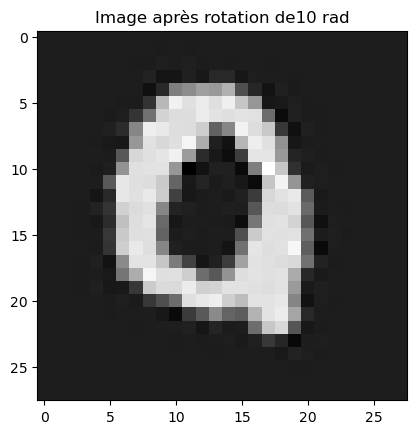

In [119]:
rotated_img = apply_transformation(x_test[3], shift_x=0, shift_y=0, angle_rad=10)
plt.imshow(rotated_img.reshape(28, 28), cmap="gray")
plt.title("Image après rotation de10 rad")
plt.show()

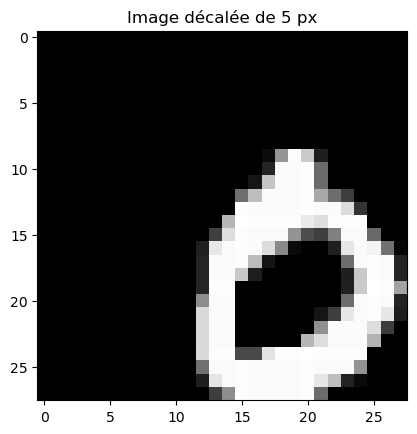

In [120]:
shift_val = 5
img_shifted = apply_transformation(x_test[3], shift_x=shift_val, shift_y=shift_val, angle_rad=0)
plt.imshow(img_shifted.reshape(28, 28), cmap="gray")
plt.title(f"Image décalée de {shift_val} px")
plt.show()


In [121]:

logits_shifted, _ = model.forward(img_shifted.reshape(1, -1))
probs_shifted = softmax(logits_shifted)[0]
print(f"Prédiction après décalage de {shift_val}px :")
predicted_details(probs_shifted)

Prédiction après décalage de 5px :
0: 0.00%
1: 0.01%
2: 0.90%
3: 0.01%
4: 1.03%
5: 0.00%
6: 0.00%
7: 42.37%
8: 0.01%
9: 55.67%


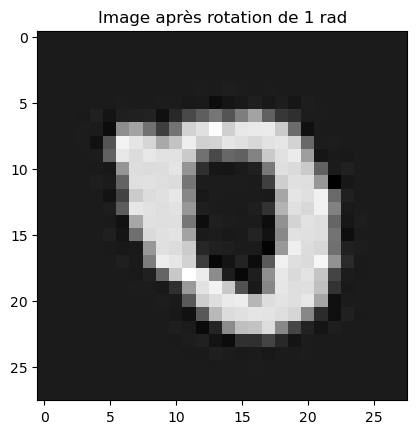

In [122]:
rot_val = 1
img_rotated = apply_transformation(x_test[3], shift_x=0, shift_y=0, angle_rad=rot_val)
plt.imshow(img_rotated.reshape(28, 28), cmap="gray")
plt.title(f"Image après rotation de {rot_val} rad")
plt.show()



In [123]:
logits_rotated, _ = model.forward(img_rotated.reshape(1, -1))
probs_rotated = softmax(logits_rotated)[0]
print(f"Prédiction après rotation de {rot_val} rad :")
predicted_details(probs_rotated)

Prédiction après rotation de 1 rad :
0: 47.48%
1: 0.00%
2: 0.00%
3: 0.01%
4: 0.07%
5: 0.27%
6: 0.03%
7: 0.65%
8: 0.01%
9: 51.48%


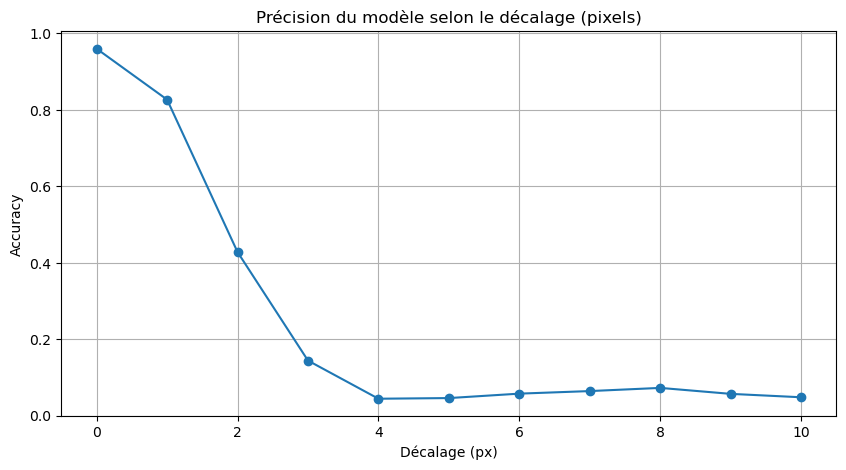

In [124]:
plt.figure(figsize=(10, 5))
plt.plot(shifts_to_test, acc_shifts, marker='o')
plt.title("Précision du modèle selon le décalage (pixels)")
plt.xlabel("Décalage (px)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

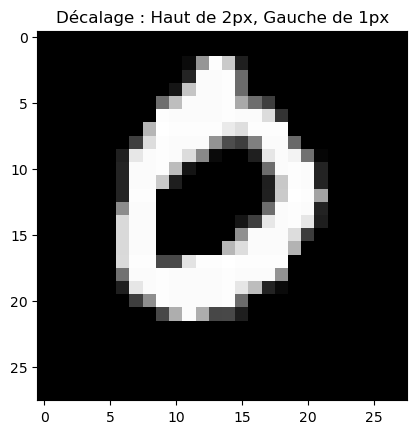

Prédiction après décalage personnalisé :
0: 25.32%
1: 0.00%
2: 19.62%
3: 0.02%
4: 0.12%
5: 0.00%
6: 0.19%
7: 0.68%
8: 1.30%
9: 52.74%


In [125]:
shift_x, shift_y = -1, -2
img_custom = apply_transformation(x_test[3], shift_x=shift_x, shift_y=shift_y, angle_rad=0)

plt.imshow(img_custom.reshape(28, 28), cmap="gray")
plt.title(f"Décalage : Haut de {abs(shift_y)}px, Gauche de {abs(shift_x)}px")
plt.show()

logits_custom, _ = model.forward(img_custom.reshape(1, -1))
probs_custom = softmax(logits_custom)[0]
print("Prédiction après décalage personnalisé :")
predicted_details(probs_custom)

In [126]:
def evaluate_per_digit(model, x_test, y_test, transformations_list, is_rotation=False):
    # Dictionnaire pour stocker les scores par chiffre
    results = {digit: [] for digit in range(10)}
    
    for val in transformations_list:
        if is_rotation:
            x_mod = np.array([apply_transformation(x, shift_x=0, shift_y=0, angle_rad=val) for x in x_test])
        else:
            x_mod = np.array([apply_transformation(x, shift_x=val, shift_y=val, angle_rad=0) for x in x_test])
            
        logits, _ = model.forward(x_mod)
        preds = np.argmax(logits, axis=1)
        
        for digit in range(10):
            mask = (y_test == digit)
            acc = np.mean(preds[mask] == y_test[mask])
            results[digit].append(acc)
            
    return results

In [127]:

shifts_to_test = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
rots_to_test = [0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4]

res_shifts = evaluate_per_digit(model, x_test, y_test, shifts_to_test, False)
res_rots = evaluate_per_digit(model, x_test, y_test, rots_to_test, True)

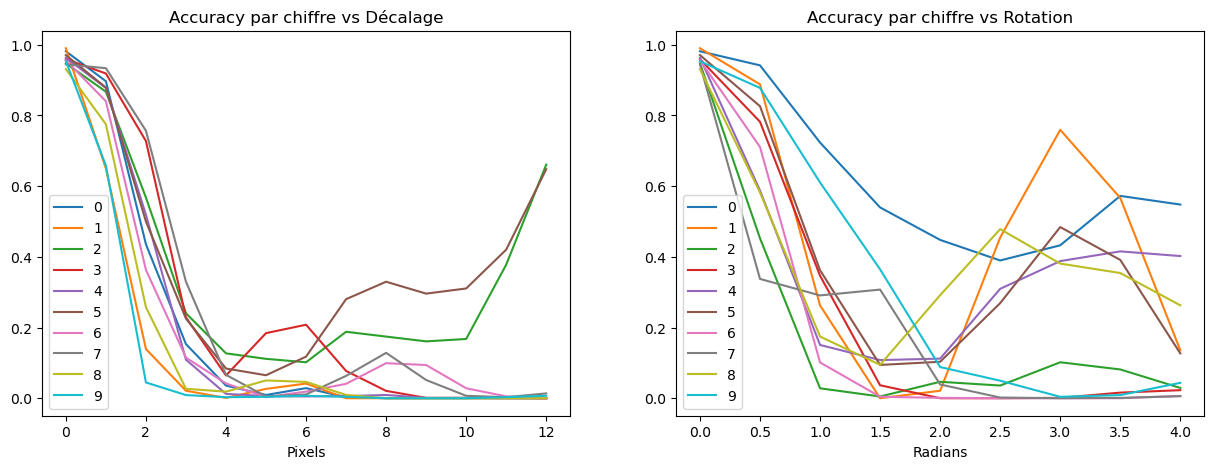

In [128]:

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

for digit in range(10):
    ax[0].plot(shifts_to_test, res_shifts[digit], label=str(digit))
    ax[1].plot(rots_to_test, res_rots[digit], label=str(digit))

ax[0].set_title("Accuracy par chiffre vs Décalage"); ax[0].set_xlabel("Pixels")
ax[1].set_title("Accuracy par chiffre vs Rotation"); ax[1].set_xlabel("Radians")
ax[0].legend(); ax[1].legend()
plt.show()

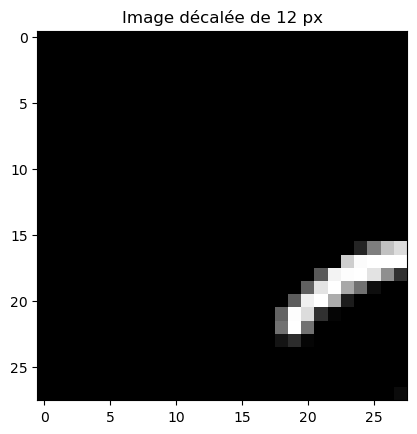

In [129]:
shift_val= 12
img_shifted = apply_transformation(x_test[35], shift_x=shift_val, shift_y=shift_val, angle_rad=0)
plt.imshow(img_shifted.reshape(28, 28), cmap="gray")
plt.title(f"Image décalée de {shift_val} px")
plt.show()

In [130]:

logits_shifted, _ = model.forward(img_shifted.reshape(1, -1))
probs_shifted = softmax(logits_shifted)[0]
print(f"Prédiction après décalage de {shift_val}px :")
predicted_details(probs_shifted)

Prédiction après décalage de 12px :
0: 2.00%
1: 10.57%
2: 61.69%
3: 4.67%
4: 2.08%
5: 7.85%
6: 5.92%
7: 1.54%
8: 3.17%
9: 0.49%


In [131]:
def generate_shift_heatmap(model, x_test, y_test, range_val=5):
    # On crée l'échantillon
    x_sample = x_test[:500]
    y_sample = y_test[:500]
    
    shifts = np.arange(-range_val, range_val + 1)
    heatmap = np.zeros((len(shifts), len(shifts)))
    
    for i, dx in enumerate(shifts):
        for j, dy in enumerate(shifts):
            # --- CORRECTION ICI : Utilisez x_sample et y_sample ---
            x_mod = np.array([apply_transformation(x, shift_x=dx, shift_y=dy, angle_rad=0) for x in x_sample])
            logits, _ = model.forward(x_mod)
            acc = np.mean(np.argmax(logits, axis=1) == y_sample)
            heatmap[j, i] = acc
            
    return heatmap, shifts

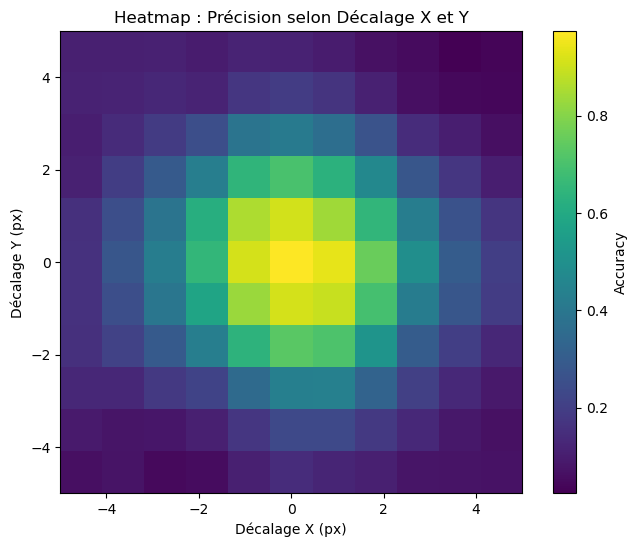

In [132]:
hm_shift, axes = generate_shift_heatmap(model, x_test, y_test)

plt.figure(figsize=(8, 6))
plt.imshow(hm_shift, extent=[axes[0], axes[-1], axes[0], axes[-1]], cmap='viridis', origin='lower')
plt.colorbar(label='Accuracy')
plt.title("Heatmap : Précision selon Décalage X et Y")
plt.xlabel("Décalage X (px)"); plt.ylabel("Décalage Y (px)")
plt.show()